# **1. Scope & Dataset Architecture**

**Subjects:** 20 subjects merged into a single dataset.

**Data Acquisition:** Each subject wore a 12-electrode EMG armband while performing 5 movement classes (with all other classes excluded) across 6 repetitions per movement.

**Signal Processing:** Raw electrical signals are filtered for noise and segmented into short 200-millisecond sliding windows.

# **2. Evaluation Strategy: Repetition-Split (Pooled)**

This is a pooled (subject-mixed) repetition-split protocol. It is leakage-free regarding repetitions—meaning no window or sample is shared between train, validation, and test sets.

# **The Fold Structure (5 Folds Total)**

**Training Set:** Remaining 4 repetitions $\times$ 20 subjects.

**Validation Set:** Repetition 3 (fixed for all subjects, used strictly for early stopping).

**Test Set:** Repetition $k \in \{1, 2, 4, 5, 6\}$ (tested globally across all subjects per fold).

---
## Step 0 — Environment

In [ ]:
import json, math, os, random, sys, time, warnings
from dataclasses import dataclass, asdict, replace as dc_replace
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io
import scipy.signal as signal
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             cohen_kappa_score, confusion_matrix, f1_score)

warnings.filterwarnings("ignore", category=RuntimeWarning)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("python  ", sys.version.split()[0], "| numpy", np.__version__,
      "| pandas", pd.__version__, "| torch", torch.__version__)
print("device  ", DEVICE)
if DEVICE.type == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"gpu      {p.name}  sm_{p.major}{p.minor}  {p.total_memory/1e9:.1f} GB")
    BF16 = torch.cuda.is_bf16_supported()
    print("bf16    ", BF16)
else:
    BF16 = False

python   3.11.14 | numpy 2.3.5 | pandas 3.0.1 | torch 2.10.0+cu128
device   cuda
gpu      NVIDIA GeForce RTX 3060 Ti  sm_86  8.6 GB
bf16     True


---
## Step 1 — Configuration

### Scope: two knobs, both at the top of `Cfg`

**Subjects:** 20 subjects (range(1, 21)).

**Class Subset & Baseline: **FAST uses a subset of 5 movements (class_subset=(0, 1, 2, 3, 4)) with a chance baseline of 0.20 and a 5-fold runtime

In [ ]:
PROJECT = Path(r"c:\Users\deskt\Desktop\Nianpro_EMG_Project")
DB2_ROOT = PROJECT / "nina_pro_db_2" / "DB2_Extracted"
RESULTS = PROJECT / "results" / "tables"
RUNS = PROJECT / "results" / "runs" / "mvstgnn_pooled"
for d in (RESULTS, RUNS):
    d.mkdir(parents=True, exist_ok=True)


@dataclass
class Cfg:
    # ---- data -------------------------------------------------------------
    fs: int = 2000
    n_channels: int = 12
    include_rest: bool = False          # rest EXCLUDED -> movement classes only

    # ---- EXPERIMENT SCOPE — the two knobs for fast iteration --------------
    # FAST (default): 20 subjects x 5 classes -> ~1.5-2 h for all 5 folds
    # FULL          : subjects=tuple(range(1, 41)), class_subset=None -> ~9 h
    subjects: tuple = tuple(range(1, 21))       # first 20 subjects
    class_subset: tuple = (0, 1, 2, 3, 4)       # first 5 movements, 0-indexed
    #                                           # None -> all 17 movements

    # ---- filtering (data-independent -> no leakage) ------------------------
    bp_low: float = 20.0
    bp_high: float = 450.0
    bp_order: int = 4
    notch_freqs: tuple = (50, 100, 150, 200, 250, 300, 350, 400)
    notch_q: float = 30.0

    # ---- segmentation / windowing ----------------------------------------
    trim_ms: int = 50
    win_ms: int = 200
    train_stride_ms: int = 40          # 40 ms for pooled (see markdown above)
    eval_stride_ms: int = 50

    # ---- normalisation: PER SUBJECT, per fold, train reps only ------------
    norm_pct: float = 99.9
    ring_channels: tuple = (0, 1, 2, 3, 4, 5, 6, 7)
    floor_frac: float = 0.05

    bad_channels: tuple = ((7, 5), (20, 5))     # verified dead electrodes

    # ---- protocol --------------------------------------------------------
    val_rep: int = 3
    test_reps: tuple = (1, 2, 4, 5, 6)

    # ---- graph -----------------------------------------------------------
    coh_band: tuple = (20.0, 150.0)
    coh_nperseg: int = 256
    coh_max_frames: int = 4000
    graph_topk: int = 6
    n_views: int = 4
    heads_per_view: int = 2
    d_attn: int = 32
    emb_dim: int = 16

    # ---- model -----------------------------------------------------------
    ms_kernels: tuple = (3, 9, 27)
    stem_width: int = 16
    d_model: int = 64
    n_st_blocks: int = 3
    n_synergies: int = 4
    head_hidden: int = 256
    p_drop: float = 0.2
    p_drop_head: float = 0.3

    # GroupNorm, NOT BatchNorm. BN pools statistics over a batch that mixes 40 subjects
    # with different distributions, and at eval its running stats are a population
    # average that fits no individual subject. GroupNorm normalises each window by its
    # own statistics -> no cross-subject contamination, no train/eval stat mismatch.
    stem_norm: str = "group"            # "group" | "batch"
    norm_groups: int = 8

    # Per-subject FiLM conditioning. Restores the per-subject adaptivity that pooling
    # destroys, while still training ONE model. Leakage-free under this protocol: every
    # test subject appears in training, so its embedding is fitted on its own TRAIN reps.
    # NOTE: a FiLM model cannot be applied to an unseen subject — fine here, but it means
    # this model is not transferable to new users without re-fitting the embedding.
    use_subject_film: bool = True
    subj_emb_dim: int = 16

    # ---- loss ------------------------------------------------------------
    label_smoothing: float = 0.05
    w_supcon: float = 0.10
    supcon_tau: float = 0.10
    w_linkpred: float = 0.01
    w_entropy: float = 0.01
    w_adj_l1: float = 1e-4
    class_weighted: bool = True
    cap_train_per_class: bool = False

    # ---- optimisation ----------------------------------------------------
    # Revised after fold-0 diagnosis: best_epoch was 29 of 30 with loss still falling,
    # i.e. badly underfit. Pooling makes the problem HARDER (one weight set for 40
    # subject-specific mappings), so it needs MORE epochs than per-subject, not fewer.
    lr: float = 1.5e-3                 # was 3e-3: 5 val decreases in the first 12 epochs
    weight_decay: float = 1e-2
    warmup_epochs: int = 5             # was 2: too short for a pooled dataset
    epochs: int = 70                   # was 30: best_epoch hit the cap
    batch_size: int = 256
    eval_batch: int = 512
    patience: int = 12                 # was 6: lets a stable run converge and stop itself
    grad_clip: float = 1.0
    amp: bool = True

    # ---- augmentation (TRAIN ONLY) ---------------------------------------
    aug_noise_snr_db: tuple = (20.0, 35.0)
    aug_amp_scale: tuple = (0.9, 1.1)
    aug_chan_drop_p: float = 0.15
    aug_time_mask_ms: int = 20

    seeds: tuple = (0,)

    # ---- derived ---------------------------------------------------------
    @property
    def win(self): return int(round(self.win_ms * self.fs / 1000))
    @property
    def trim(self): return int(round(self.trim_ms * self.fs / 1000))
    @property
    def train_stride(self): return int(round(self.train_stride_ms * self.fs / 1000))
    @property
    def eval_stride(self): return int(round(self.eval_stride_ms * self.fs / 1000))
    @property
    def n_classes(self):
        if self.class_subset is not None:
            return len(self.class_subset)
        return 18 if self.include_rest else 17
    @property
    def label_map(self):
        """original 0-indexed movement label -> contiguous training label (or None)."""
        if self.class_subset is None:
            return None
        return {c: i for i, c in enumerate(self.class_subset)}
    @property
    def n_movement_classes(self):
        """movement classes kept, excluding rest — used for the segment-count check."""
        return len(self.class_subset) if self.class_subset is not None else 17
    @property
    def n_folds(self): return len(self.test_reps)

    def train_reps(self, test_rep):
        return tuple(r for r in range(1, 7) if r not in (self.val_rep, test_rep))

    def bad_for(self, subject):
        return [c for s, c in self.bad_channels if s == subject]


CFG = Cfg()
print("=" * 68)
print("EXPERIMENT SCOPE")
print("=" * 68)
print(f"subjects           {len(CFG.subjects)}  {CFG.subjects[0]}..{CFG.subjects[-1]}")
if CFG.class_subset is None:
    print(f"classes            all {CFG.n_classes} movements")
else:
    print(f"classes            {CFG.n_classes} of 17 -> original labels "
          f"{list(CFG.class_subset)} (0-indexed) = DB2 movements "
          f"{[c+1 for c in CFG.class_subset]}")
    print(f"                   remapped to 0..{CFG.n_classes-1} for training")
print(f"chance level       {1.0/CFG.n_classes:.4f}   "
      f"<-- {CFG.n_classes}-class accuracy is NOT comparable to 17-class")
print(f"rest class         {'EXCLUDED' if not CFG.include_rest else 'included'}")
print("=" * 68)
print(f"window             {CFG.win} samples ({CFG.win_ms} ms)")
print(f"strides            train {CFG.train_stride} ({CFG.train_stride_ms} ms)"
      f"  eval {CFG.eval_stride} ({CFG.eval_stride_ms} ms)")
print(f"subjects           {len(CFG.subjects)}  MERGED into one dataset")
print(f"models to train    {CFG.n_folds}  (one per fold)")
for tr in CFG.test_reps:
    print(f"  test rep {tr} | val rep {CFG.val_rep} | train reps {CFG.train_reps(tr)}"
          f"   (same split applied to ALL subjects)")

EXPERIMENT SCOPE
subjects           20  1..20
classes            5 of 17 -> original labels [0, 1, 2, 3, 4] (0-indexed) = DB2 movements [1, 2, 3, 4, 5]
                   remapped to 0..4 for training
chance level       0.2000   <-- 5-class accuracy is NOT comparable to 17-class
rest class         EXCLUDED
window             400 samples (200 ms)
strides            train 80 (40 ms)  eval 100 (50 ms)
subjects           20  MERGED into one dataset
models to train    5  (one per fold)
  test rep 1 | val rep 3 | train reps (2, 4, 5, 6)   (same split applied to ALL subjects)
  test rep 2 | val rep 3 | train reps (1, 4, 5, 6)   (same split applied to ALL subjects)
  test rep 4 | val rep 3 | train reps (1, 2, 5, 6)   (same split applied to ALL subjects)
  test rep 5 | val rep 3 | train reps (1, 2, 4, 6)   (same split applied to ALL subjects)
  test rep 6 | val rep 3 | train reps (1, 2, 4, 5)   (same split applied to ALL subjects)


---
## Step 2 — Load, filter, segment (all subjects, once)

Filtering uses fixed coefficients, so it is leakage-free and done once up front.

In [ ]:
def build_filter_cascade(cfg):
    sections = [signal.butter(cfg.bp_order, [cfg.bp_low, cfg.bp_high],
                              btype="band", fs=cfg.fs, output="sos")]
    for f0 in cfg.notch_freqs:
        if f0 < cfg.fs / 2:
            b, a = signal.iirnotch(f0, cfg.notch_q, fs=cfg.fs)
            sections.append(signal.tf2sos(b, a))
    return np.concatenate(sections, axis=0)


SOS = build_filter_cascade(CFG)


def load_raw(subject, cfg=CFG):
    path = DB2_ROOT / f"DB2_s{subject}" / f"S{subject}_E1_A1.mat"
    try:
        m = scipy.io.loadmat(str(path))
        emg = np.asarray(m["emg"], dtype=np.float32)
        rs = np.asarray(m["restimulus"]).ravel().astype(np.int8)
        rr = np.asarray(m["rerepetition"]).ravel().astype(np.int8)
    except NotImplementedError:
        import h5py
        with h5py.File(path, "r") as f:
            emg = np.asarray(f["emg"], dtype=np.float32).T
            rs = np.asarray(f["restimulus"]).ravel().astype(np.int8)
            rr = np.asarray(f["rerepetition"]).ravel().astype(np.int8)
    assert emg.shape[1] == cfg.n_channels and len(rs) == len(rr) == len(emg)
    return emg, rs, rr


def filter_signal(emg, sos):
    return np.ascontiguousarray(
        signal.sosfiltfilt(sos, emg.astype(np.float64), axis=0), dtype=np.float32)


def extract_segments(rs, rr, cfg=CFG):
    """Contiguous runs of constant (restimulus, rerepetition), edge-trimmed."""
    key = rs.astype(np.int64) * 100 + rr.astype(np.int64)
    brk = np.flatnonzero(np.diff(key)) + 1
    starts, ends = np.r_[0, brk], np.r_[brk, len(key)]
    raw = [(int(s), int(e), int(rs[s]), int(rr[s])) for s, e in zip(starts, ends)]
    if cfg.include_rest:
        raw = [(s, e, lab, (next((raw[j][3] for j in range(i + 1, len(raw))
                                 if raw[j][2] != 0), 0) if lab == 0 else rep))
               for i, (s, e, lab, rep) in enumerate(raw)]
    lmap = cfg.label_map
    segs, dropped, off_subset = [], 0, 0
    for s, e, lab, rep in raw:
        if lab == 0 and not cfg.include_rest:
            continue
        if not 1 <= rep <= 6:
            dropped += 1
            continue
        y = 17 if lab == 0 else lab - 1  # 0-indexed movement label
        if lmap is not None:      # class subset: drop + remap
            if y not in lmap:
                off_subset += 1
                continue
            y = lmap[y]
        s2, e2 = s + cfg.trim, e - cfg.trim
        if e2 - s2 < cfg.win:
            dropped += 1
            continue
        segs.append((s2, e2, y, rep))
    return segs, dropped


def load_all_subjects(subjects, cfg=CFG, verbose=True):
    """-> (SUBJ dict, offsets array, n_total). Raw filtered signals held in RAM."""
    SUBJ, t0 = {}, time.time()
    for i, s in enumerate(subjects):
        emg, rs, rr = load_raw(s, cfg)
        bad = cfg.bad_for(s)
        for c in bad:
            emg[:, c] = 0.0   # verified dead electrodes
        sig = filter_signal(emg, SOS)
        segs, dropped = extract_segments(rs, rr, cfg)
        if not cfg.include_rest:
            exp = 6 * cfg.n_movement_classes   # 6 repetitions per movement
            assert len(segs) == exp, \
                f"subject {s}: {len(segs)} segments, expected {exp}"
        SUBJ[s] = dict(sig=sig, segs=segs, n=len(sig), bad=bad)
        if verbose and (i % 5 == 0 or i == len(subjects) - 1):
            gb = sum(v["sig"].nbytes for v in SUBJ.values()) / 1e9
            print(f"  [{i+1:>2}/{len(subjects)}] s{s:<3} {len(sig):>9,} samples  "
                  f"{len(segs)} segs  dead {bad or '-'}   RAM {gb:.2f} GB  "
                  f"{time.time()-t0:.0f}s")
    lens = np.array([SUBJ[s]["n"] for s in subjects], dtype=np.int64)
    offsets = np.r_[0, np.cumsum(lens)[:-1]]
    return SUBJ, offsets, int(lens.sum())


SUBJECTS = list(CFG.subjects)
print(f"loading {len(SUBJECTS)} subjects (~90 s, ~3.5 GB RAM) ...")
SUBJ, OFFSETS, N_TOTAL = load_all_subjects(SUBJECTS, CFG)
print(f"\nmerged: {N_TOTAL:,} samples across {len(SUBJECTS)} subjects "
      f"({N_TOTAL/CFG.fs/60:.0f} min of EMG)")
print(f"RAM (float32 raw)      {N_TOTAL*12*4/1e9:.2f} GB")
print(f"GPU (float16 per fold) {N_TOTAL*12*2/1e9:.2f} GB")

loading 20 subjects (~90 s, ~3.5 GB RAM) ...
  [ 1/20] s1   1,808,331 samples  30 segs  dead -   RAM 0.09 GB  2s
  [ 6/20] s6   1,797,578 samples  30 segs  dead -   RAM 0.52 GB  13s
  [11/20] s11  1,803,896 samples  30 segs  dead -   RAM 0.95 GB  23s
  [16/20] s16  1,801,903 samples  30 segs  dead -   RAM 1.38 GB  33s
  [20/20] s20  1,801,389 samples  30 segs  dead [5]   RAM 1.73 GB  41s

merged: 36,027,660 samples across 20 subjects (300 min of EMG)
RAM (float32 raw)      1.73 GB
GPU (float16 per fold) 0.86 GB


---
## Step 3 — Global window index

Each subject occupies a **disjoint contiguous block** of one merged sample axis, so a window's
global start is `local_start + offsets[subject]`. Gathering is then a single fancy-index into one
buffer, exactly as in the per-subject notebook — the pooling adds no per-batch bookkeeping.

Each window carries `subj_idx` so the model can look up that subject's `A_coh`.

In [ ]:
def build_windows(segs, stride, cfg=CFG):
    starts, labels, reps, segids = [], [], [], []
    for sid, (s, e, y, rep) in enumerate(segs):
        last = e - cfg.win
        if last < s:
            continue
        st = np.arange(s, last + 1, stride, dtype=np.int64)
        starts.append(st)
        labels.append(np.full(len(st), y, dtype=np.int64))
        reps.append(np.full(len(st), rep, dtype=np.int64))
        segids.append(np.full(len(st), sid, dtype=np.int64))
    if not starts:
        return {k: np.zeros(0, np.int64) for k in ("start", "label", "rep", "seg_id")}
    return dict(start=np.concatenate(starts), label=np.concatenate(labels),
                rep=np.concatenate(reps), seg_id=np.concatenate(segids))


def subset(win, mask):
    return {k: v[mask] for k, v in win.items()}


KEYS = ("start", "label", "rep", "seg_id", "subj_idx")


def build_pooled_index(SUBJ, subjects, offsets, stride, reps, cfg=CFG):
    """Merged window index over the given repetitions, for ALL subjects."""
    parts = []
    for si, s in enumerate(subjects):
        w = build_windows(SUBJ[s]["segs"], stride, cfg)
        w = subset(w, np.isin(w["rep"], reps))
        w["start"] = w["start"] + offsets[si]
        w["seg_id"] = w["seg_id"] + si * 1000          # globally unique
        w["subj_idx"] = np.full(len(w["start"]), si, dtype=np.int64)
        parts.append(w)
    return {k: np.concatenate([p[k] for p in parts]) for k in KEYS}


def fold_indices(SUBJ, subjects, offsets, fold, cfg=CFG):
    test_rep = cfg.test_reps[fold]
    train_reps = cfg.train_reps(test_rep)
    tr = build_pooled_index(SUBJ, subjects, offsets, cfg.train_stride, train_reps, cfg)
    va = build_pooled_index(SUBJ, subjects, offsets, cfg.eval_stride, (cfg.val_rep,), cfg)
    te = build_pooled_index(SUBJ, subjects, offsets, cfg.eval_stride, (test_rep,), cfg)
    meta = dict(fold=fold, test_rep=test_rep, val_rep=cfg.val_rep,
                train_reps=list(train_reps), n_train=len(tr["start"]),
                n_val=len(va["start"]), n_test=len(te["start"]))
    return tr, va, te, meta


print(f"{'fold':>4}{'test':>6}{'train reps':>16}{'n_train':>11}{'n_val':>9}{'n_test':>9}"
      f"{'steps/ep':>10}")
for f in range(CFG.n_folds):
    tr, va, te, m = fold_indices(SUBJ, SUBJECTS, OFFSETS, f, CFG)
    print(f"{f:>4}{m['test_rep']:>6}{str(m['train_reps']):>16}{m['n_train']:>11,}"
          f"{m['n_val']:>9,}{m['n_test']:>9,}"
          f"{math.ceil(m['n_train']/CFG.batch_size):>10,}")
_tr, _va, _te, _m = fold_indices(SUBJ, SUBJECTS, OFFSETS, 0, CFG)
print(f"\nper-class train windows (fold 0): "
      f"{np.bincount(_tr['label'], minlength=CFG.n_classes)}")
_c = np.bincount(_tr["label"], minlength=CFG.n_classes)
print(f"imbalance max/min = {_c.max()/_c.min():.2f}x  "
      f"(class_weighted={CFG.class_weighted}, cap={CFG.cap_train_per_class})")
print(f"subjects per fold: train {len(np.unique(_tr['subj_idx']))}, "
      f"val {len(np.unique(_va['subj_idx']))}, test {len(np.unique(_te['subj_idx']))}")

fold  test      train reps    n_train    n_val   n_test  steps/ep
   0     1    [2, 4, 5, 6]     46,889    9,276    9,679       184
   1     2    [1, 4, 5, 6]     47,173    9,276    9,457       185
   2     4    [1, 2, 5, 6]     47,151    9,276    9,476       185
   3     5    [1, 2, 4, 6]     47,488    9,276    9,212       186
   4     6    [1, 2, 4, 5]     47,207    9,276    9,426       185

per-class train windows (fold 0): [11615 10103  8889  8400  7882]
imbalance max/min = 1.47x  (class_weighted=True, cap=False)
subjects per fold: train 20, val 20, test 20


---
## Step 4 — Leakage tests

Pooling adds two failure modes that the per-subject version could not have, so both are tested:

- **Block containment** — a window near the end of subject *S*'s block must not run past
  `offsets[S] + n_S` into subject *S+1*'s samples.
- **Global rep consistency** — fold *k* must test rep *k* for **every** subject, not a mix.

In [ ]:
def leakage_tests_pooled(SUBJ, subjects, offsets, n_total, cfg=CFG, verbose=True):
    results = []

    def chk(name, ok, detail=""):
        results.append((name, bool(ok), detail))
        if verbose and (not ok or detail):
            print(f"  [{'PASS' if ok else 'FAIL'}] {name}" + (f" — {detail}" if detail else ""))
        elif verbose:
            print(f"  [{'PASS' if ok else 'FAIL'}] {name}")

    # ---- block layout is disjoint and contiguous --------------------------
    lens = np.array([SUBJ[s]["n"] for s in subjects])
    ends = offsets + lens
    chk("subject blocks disjoint & contiguous",
        bool(np.all(offsets[1:] == ends[:-1])) and int(ends[-1]) == n_total,
        f"n_total={n_total:,}")

    for f in range(cfg.n_folds):
        tr, va, te, m = fold_indices(SUBJ, subjects, offsets, f, cfg)
        tag = f"fold{f}(test rep {m['test_rep']})"

        # ---- every window inside its own subject's block ------------------
        ok = True
        for w in (tr, va, te):
            lo = offsets[w["subj_idx"]]
            hi = lo + lens[w["subj_idx"]]
            if not (np.all(w["start"] >= lo) and np.all(w["start"] + cfg.win <= hi)):
                ok = False
        chk(f"{tag} windows inside own subject block", ok)

        # ---- fold tests the SAME rep for every subject --------------------
        chk(f"{tag} single test rep across all subjects",
            set(te["rep"]) == {m["test_rep"]} and set(va["rep"]) == {cfg.val_rep}
            and set(tr["rep"]) == set(m["train_reps"]),
            f"test={sorted(set(te['rep']))} val={sorted(set(va['rep']))} "
            f"train={sorted(set(tr['rep']))}")

        chk(f"{tag} all {len(subjects)} subjects present in every split",
            all(len(np.unique(w["subj_idx"])) == len(subjects) for w in (tr, va, te)))

        # ---- per-subject: zero shared SAMPLE between splits ---------------
        worst = 0
        for si in range(len(subjects)):
            cov = {}
            for nm, w in (("train", tr), ("val", va), ("test", te)):
                ws = w["start"][w["subj_idx"] == si] - offsets[si]
                c = np.zeros(lens[si], dtype=bool)
                if len(ws):
                    c[(ws[:, None] + np.arange(cfg.win)[None, :]).ravel()] = True
                cov[nm] = c
            worst = max(worst,
                        int((cov["train"] & cov["val"]).sum()),
                        int((cov["train"] & cov["test"]).sum()),
                        int((cov["val"] & cov["test"]).sum()))
        chk(f"{tag} zero sample overlap (all {len(subjects)} subjects)", worst == 0,
            f"max shared samples = {worst}")

        # ---- segments disjoint -------------------------------------------
        g = [set(w["seg_id"]) for w in (tr, va, te)]
        chk(f"{tag} segments disjoint",
            not (g[0] & g[1]) and not (g[0] & g[2]) and not (g[1] & g[2]))

    chk("val rep never used as a test rep", cfg.val_rep not in cfg.test_reps)
    return results


print("running pooled leakage gate ...")
_res = leakage_tests_pooled(SUBJ, SUBJECTS, OFFSETS, N_TOTAL, CFG)
_fail = [n for n, ok, _ in _res if not ok]
print(f"\n{len(_res)-len(_fail)}/{len(_res)} checks passed")
assert not _fail, f"LEAKAGE DETECTED: {_fail}"
print("Leakage gate: GREEN")

running pooled leakage gate ...
  [PASS] subject blocks disjoint & contiguous — n_total=36,027,660
  [PASS] fold0(test rep 1) windows inside own subject block
  [PASS] fold0(test rep 1) single test rep across all subjects — test=[np.int64(1)] val=[np.int64(3)] train=[np.int64(2), np.int64(4), np.int64(5), np.int64(6)]
  [PASS] fold0(test rep 1) all 20 subjects present in every split
  [PASS] fold0(test rep 1) zero sample overlap (all 20 subjects) — max shared samples = 0
  [PASS] fold0(test rep 1) segments disjoint
  [PASS] fold1(test rep 2) windows inside own subject block
  [PASS] fold1(test rep 2) single test rep across all subjects — test=[np.int64(2)] val=[np.int64(3)] train=[np.int64(1), np.int64(4), np.int64(5), np.int64(6)]
  [PASS] fold1(test rep 2) all 20 subjects present in every split
  [PASS] fold1(test rep 2) zero sample overlap (all 20 subjects) — max shared samples = 0
  [PASS] fold1(test rep 2) segments disjoint
  [PASS] fold2(test rep 4) windows inside own subject blo

---
## Step 5 — Per-subject normalisation and the pooled GPU buffer



In [ ]:
def compute_scale(sig, segs, train_reps, cfg=CFG):
    """Per-channel divisor from this subject's TRAIN reps only."""
    mask = np.zeros(len(sig), dtype=bool)
    for s, e, _, rep in segs:
        if rep in train_reps:
            mask[s:e] = True
    p = np.percentile(np.abs(sig[mask]), cfg.norm_pct, axis=0).astype(np.float64)
    ref = float(np.median(p[list(cfg.ring_channels)]))
    floor = cfg.floor_frac * ref
    return np.maximum(p, floor).astype(np.float32), int((p < floor).sum())


class PooledSource:
    """One merged float16 buffer of per-subject-normalised signal, resident on GPU."""

    def __init__(self, n_total, cfg=CFG, device=DEVICE):
        self.cfg, self.device = cfg, device
        self.buf = torch.zeros((n_total, cfg.n_channels), dtype=torch.float16, device=device)
        self.ar = torch.arange(cfg.win, device=device)

    def write(self, offset, sig, scale):
        x = np.clip(sig / scale, -1.0, 1.0)
        self.buf[offset:offset + len(x)] = torch.from_numpy(x).to(self.device, torch.float16)

    def nbytes(self):
        return self.buf.numel() * self.buf.element_size()

    def gather(self, starts, train, gen=None):
        idx = starts[:, None] + self.ar[None, :]
        x = self.buf[idx].to(torch.float32).permute(0, 2, 1).contiguous()   # (B,12,win)
        return self._augment(x, gen) if train else x

    def _augment(self, x, gen=None):
        cfg, dev = self.cfg, x.device
        B, C, L = x.shape
        r = lambda *s: torch.rand(*s, device=dev, generator=gen)
        lo, hi = cfg.aug_amp_scale
        x = x * (lo + (hi - lo) * r(B, C, 1))
        slo, shi = cfg.aug_noise_snr_db
        snr = slo + (shi - slo) * r(B, 1, 1)
        rms = x.pow(2).mean(dim=2, keepdim=True).sqrt()
        x = x + rms * torch.pow(10.0, -snr / 20.0) * torch.randn(
            x.shape, device=dev, generator=gen)
        if cfg.aug_chan_drop_p > 0:
            hit = (r(B, 1) < cfg.aug_chan_drop_p).to(x.dtype)
            which = torch.randint(0, C, (B,), device=dev, generator=gen)
            x = x * (1.0 - F.one_hot(which, C).to(x.dtype) * hit).unsqueeze(-1)
        span = int(round(cfg.aug_time_mask_ms * cfg.fs / 1000))
        if span > 0:
            t0 = torch.randint(0, max(1, L - span), (B, 1), device=dev, generator=gen)
            ta = torch.arange(L, device=dev)[None, :]
            x = x * (~((ta >= t0) & (ta < t0 + span)))[:, None, :].to(x.dtype)
        return x


class Batcher:
    """Index tensors resident on GPU; yields (starts, labels, subj_idx) per batch."""

    def __init__(self, win, device=DEVICE):
        self.start = torch.from_numpy(win["start"]).to(device)
        self.label = torch.from_numpy(win["label"]).to(device)
        self.subj = torch.from_numpy(win["subj_idx"]).to(device)
        self.n = len(win["start"])
        self.device = device

    def epoch(self, batch, shuffle, rng=None):
        order = np.arange(self.n)
        if shuffle:
            (rng or np.random).shuffle(order)
        for i in range(0, self.n, batch):
            sel = torch.from_numpy(order[i:i + batch]).to(self.device)
            yield self.start[sel], self.label[sel], self.subj[sel]


_t = time.time()
_scales, _nfl = {}, 0
for _si, _s in enumerate(SUBJECTS):
    _sc, _f = compute_scale(SUBJ[_s]["sig"], SUBJ[_s]["segs"], CFG.train_reps(1), CFG)
    _scales[_s] = _sc
    _nfl += _f
    if _f:
        print(f"  subject {_s}: {_f} channel(s) hit the scale floor "
              f"(dead {SUBJ[_s]['bad']})")
print(f"\nper-subject scales computed in {time.time()-_t:.1f}s, "
      f"{_nfl} floored channel(s) total")
_p = np.array([_scales[s].max() for s in SUBJECTS])
print(f"across-subject spread of max channel scale: "
      f"{_p.min()*1e5:.1f}e-5 .. {_p.max()*1e5:.1f}e-5  ({_p.max()/_p.min():.1f}x)")
print("^ this spread is exactly why normalisation must be PER SUBJECT when pooling")

  subject 7: 1 channel(s) hit the scale floor (dead [5])
  subject 20: 1 channel(s) hit the scale floor (dead [5])

per-subject scales computed in 0.6s, 2 floored channel(s) total
across-subject spread of max channel scale: 15.1e-5 .. 569.7e-5  (37.7x)
^ this spread is exactly why normalisation must be PER SUBJECT when pooling


---
## Step 6 — Graph

`A_anat` and `A_learn` are global; `A_coh` is **per subject**,  and
indexed per batch by `subj_idx`.

In [ ]:
def build_A_anat(n=12):
    A = np.zeros((n, n), dtype=np.float64)

    def link(i, j, w):
        A[i, j] = max(A[i, j], w); A[j, i] = max(A[j, i], w)

    for i in range(8):
        link(i, (i + 1) % 8, 1.0)
        link(i, (i + 2) % 8, 0.5)
    for c in (8, 9):
        for i in range(8):
            link(c, i, 0.3)      # FDS/EDS: ring orientation undocumented -> uniform weak
    link(8, 9, 0.3)
    link(10, 11, 1.0)
    for c in (10, 11):
        for i in range(8):
            link(c, i, 0.1)
    A = A + np.eye(n)
    dm = 1.0 / np.sqrt(A.sum(1))
    return (A * dm[:, None] * dm[None, :]).astype(np.float32)


def sym_norm_topk(A, topk):
    n = A.shape[0]
    M = np.array(A, dtype=np.float64)
    np.fill_diagonal(M, 0.0)
    keep = np.zeros_like(M, dtype=bool)
    if topk < n - 1:
        for i in range(n):
            keep[i, np.argsort(-M[i])[:topk]] = True
        keep |= keep.T
    else:
        keep[:] = True
    M = M * keep + np.eye(n)
    dm = 1.0 / np.sqrt(np.maximum(M.sum(1), 1e-12))
    return (M * dm[:, None] * dm[None, :]).astype(np.float32)


def compute_A_coh(sig, segs, train_reps, cfg=CFG, seed=0):
    nper, hop = cfg.coh_nperseg, cfg.coh_nperseg // 2
    frames = []
    for s, e, _, rep in segs:
        if rep not in train_reps:
            continue
        seg = sig[s:e]
        nf = (len(seg) - nper) // hop + 1
        if nf > 0:
            idx = np.arange(nper)[None, :] + (np.arange(nf) * hop)[:, None]
            frames.append(seg[idx])
    if not frames:
        return build_A_anat(cfg.n_channels)
    Fr = np.concatenate(frames, axis=0)
    if len(Fr) > cfg.coh_max_frames:
        Fr = Fr[np.random.default_rng(seed).choice(len(Fr), cfg.coh_max_frames, replace=False)]
    X = np.fft.rfft(Fr * np.hanning(nper).astype(np.float32)[None, :, None], axis=1)
    fr = np.fft.rfftfreq(nper, 1.0 / cfg.fs)
    X = X[:, (fr >= cfg.coh_band[0]) & (fr <= cfg.coh_band[1]), :]
    nf = X.shape[0]
    Pxy = np.einsum("nfi,nfj->fij", X, np.conj(X)) / nf
    Pxx = np.real(np.einsum("nfi,nfi->fi", X, np.conj(X))) / nf
    msc = np.abs(Pxy) ** 2 / (Pxx[:, :, None] * Pxx[:, None, :] + 1e-20)
    return sym_norm_topk(msc.mean(axis=0), cfg.graph_topk)


def build_A_coh_all(SUBJ, subjects, train_reps, cfg=CFG):
    """-> (n_subjects, 12, 12) tensor; row si is subject si's train-fitted coherence."""
    A = np.stack([compute_A_coh(SUBJ[s]["sig"], SUBJ[s]["segs"], train_reps, cfg)
                  for s in subjects])
    return torch.from_numpy(A).to(DEVICE)


A_ANAT = torch.from_numpy(build_A_anat(CFG.n_channels)).to(DEVICE)
_t = time.time()
_Acoh_all = build_A_coh_all(SUBJ, SUBJECTS, CFG.train_reps(1), CFG)
print(f"A_coh for {len(SUBJECTS)} subjects in {time.time()-_t:.1f}s -> "
      f"{tuple(_Acoh_all.shape)}")
_off = (_Acoh_all - _Acoh_all.mean(0)).abs().mean().item()
print(f"mean |A_coh - population mean| = {_off:.4f}  "
      "(non-zero => subjects genuinely differ, per-sample lookup is doing work)")

A_coh for 20 subjects in 1.5s -> (20, 12, 12)
mean |A_coh - population mean| = 0.0201  (non-zero => subjects genuinely differ, per-sample lookup is doing work)


---
## Step 7 — MV-STGNN (pooled variant)

Identical to the per-subject architecture except the graph conv now **dispatches on adjacency
rank**, so a single view can be global `(N,N)`, per-sample `(B,N,N)`, or per-sample-per-time
`(B,T,N,N)`:

| View | Rank | Source |
|---|---|---|
| `A_anat` | `(N,N)` | fixed geometry |
| `A_coh` | `(B,N,N)` | **per subject**, train-fitted, looked up by `subj_idx` |
| `A_dyn` | `(B,T,N,N)` | input-conditioned attention |
| `A_learn` | `(N,N)` | global learned parameters |

Two further changes made after diagnosing the first run:

**GroupNorm instead of BatchNorm**

**Per-subject FiLM conditioning**

In [ ]:
def gconv(A, vv):
    """A: (N,N) | (B,N,N) | (B,T,N,N);  vv: (B,T,h,N,hd) -> same shape as vv."""
    A = A.to(vv.dtype)
    if A.dim() == 2:
        return torch.einsum("ij,bthjd->bthid", A, vv)
    if A.dim() == 3:
        return torch.einsum("bij,bthjd->bthid", A, vv)
    return torch.einsum("btij,bthjd->bthid", A, vv)


def as_pooled_adj(A, B, N, dtype):
    """Reduce any adjacency rank to (B,N,N) for the synergy link-prediction loss."""
    A = A.to(dtype)
    if A.dim() == 2:
        return A.expand(B, N, N)
    if A.dim() == 3:
        return A
    return A.mean(1)


def make_norm(cfg, c):
    """GroupNorm by default — see Cfg.stem_norm for why BatchNorm hurts pooled training."""
    if cfg.stem_norm == "batch":
        return nn.BatchNorm1d(c)
    g = math.gcd(cfg.norm_groups, c) or 1
    return nn.GroupNorm(g, c)


class TCNBlock(nn.Module):
    def __init__(self, cfg, cin, cout, k, dil, p):
        super().__init__()
        self.conv = nn.Conv1d(cin, cout, k, dilation=dil, padding=dil * (k - 1) // 2)
        self.bn = make_norm(cfg, cout); self.act = nn.GELU(); self.do = nn.Dropout(p)
        self.res = nn.Conv1d(cin, cout, 1) if cin != cout else nn.Identity()

    def forward(self, x):
        return self.do(self.act(self.bn(self.conv(x)))) + self.res(x)


class SubjectFiLM(nn.Module):
    """Per-subject affine modulation of node features: h <- h*(1+g_s) + b_s.

    Zero-initialised projection, so the model starts exactly at the un-conditioned
    solution and only learns per-subject deviations if they help.
    """

    def __init__(self, n_subjects, emb_dim, d):
        super().__init__()
        self.emb = nn.Embedding(n_subjects, emb_dim)
        self.to_gb = nn.Linear(emb_dim, 2 * d)
        nn.init.normal_(self.emb.weight, std=0.02)
        nn.init.zeros_(self.to_gb.weight)
        nn.init.zeros_(self.to_gb.bias)

    def forward(self, h, subj):                       # h (B,T,N,D), subj (B,)
        g, b = self.to_gb(self.emb(subj)).chunk(2, dim=-1)
        return h * (1.0 + g[:, None, None, :]) + b[:, None, None, :]


class Stem(nn.Module):
    """Per-channel temporal encoder, weights SHARED across electrodes and subjects."""

    def __init__(self, cfg):
        super().__init__()
        self.ms = nn.ModuleList([nn.Conv1d(1, cfg.stem_width, k, padding=k // 2)
                                 for k in cfg.ms_kernels])
        c = cfg.stem_width * len(cfg.ms_kernels)
        self.bn = make_norm(cfg, c); self.act = nn.GELU(); self.pool = nn.MaxPool1d(4)
        d = cfg.d_model
        self.b1 = TCNBlock(cfg, c, d, 5, 1, cfg.p_drop)
        self.b2 = TCNBlock(cfg, d, d, 5, 2, cfg.p_drop)
        self.b3 = TCNBlock(cfg, d, d, 5, 4, cfg.p_drop)
        self.dn = nn.AvgPool1d(2)

    def forward(self, x):
        B, C, L = x.shape
        h = x.reshape(B * C, 1, L)
        h = torch.cat([m(h) for m in self.ms], dim=1)
        h = self.pool(self.act(self.bn(h)))
        h = self.dn(self.b1(h)); h = self.dn(self.b2(h)); h = self.b3(h)
        D, T = h.shape[1], h.shape[2]
        return h.reshape(B, C, D, T).permute(0, 3, 1, 2)          # (B,T,N,D)


class MultiViewGraphConv(nn.Module):
    def __init__(self, cfg, n_nodes, use_static=True):
        super().__init__()
        self.use_static = use_static
        self.n_views = cfg.n_views if use_static else 2
        self.hpv = cfg.heads_per_view
        self.H = self.n_views * self.hpv
        d = cfg.d_model
        self.hd = max(1, d // self.H)
        self.proj = nn.Linear(d, self.H * self.hd)
        self.out = nn.Linear(self.H * self.hd, d)
        self.q = nn.Linear(d, cfg.d_attn); self.k = nn.Linear(d, cfg.d_attn)
        self.E1 = nn.Parameter(torch.randn(n_nodes, cfg.emb_dim) * 0.1)
        self.E2 = nn.Parameter(torch.randn(n_nodes, cfg.emb_dim) * 0.1)
        self.topk = min(cfg.graph_topk, n_nodes)

    def forward(self, h, A_anat=None, A_coh=None):
        B, T, N, D = h.shape
        v = self.proj(h).view(B, T, N, self.H, self.hd).permute(0, 1, 3, 2, 4)
        q, k = self.q(h), self.k(h)
        s = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(q.shape[-1])
        if self.topk < N:
            s = s.masked_fill(s < s.topk(self.topk, dim=-1).values[..., -1:], float("-inf"))
        A_dyn = s.softmax(-1)
        A_learn = torch.softmax(F.relu(self.E1 @ self.E2.t()), dim=-1)
        views = [A_anat, A_coh, A_dyn, A_learn] if self.use_static else [A_dyn, A_learn]

        parts, pooled = [], []
        for vi, A in enumerate(views):
            sl = slice(vi * self.hpv, (vi + 1) * self.hpv)
            parts.append(gconv(A, v[:, :, sl]))
            pooled.append(as_pooled_adj(A, B, N, h.dtype))
        o = torch.cat(parts, dim=2).permute(0, 1, 3, 2, 4).reshape(B, T, N, self.H * self.hd)
        return self.out(o), torch.stack(pooled, 0).mean(0), A_dyn


class TemporalGate(nn.Module):
    def __init__(self, d, k=5, dil=1):
        super().__init__()
        self.conv = nn.Conv1d(d, 2 * d, k, dilation=dil,
                              padding=dil * (k - 1) // 2, groups=d)

    def forward(self, h):
        B, T, N, D = h.shape
        x = h.permute(0, 2, 3, 1).reshape(B * N, D, T)
        y = self.conv(x).view(B * N, D, 2, T)          # grouped conv: order is (group, j)
        y = torch.tanh(y[:, :, 0]) * torch.sigmoid(y[:, :, 1])
        return y.view(B, N, D, T).permute(0, 3, 1, 2)


class STBlock(nn.Module):
    def __init__(self, cfg, n_nodes, dil, use_static=True):
        super().__init__()
        d = cfg.d_model
        self.g = MultiViewGraphConv(cfg, n_nodes, use_static)
        self.t = TemporalGate(d, 5, dil)
        self.n1 = nn.LayerNorm(d); self.n2 = nn.LayerNorm(d)
        self.do = nn.Dropout(cfg.p_drop)

    def forward(self, h, A_anat=None, A_coh=None):
        g, A_f, A_d = self.g(self.n1(h), A_anat, A_coh)
        h = h + self.do(g)
        h = h + self.do(self.t(self.n2(h)))
        return h, A_f, A_d


class SynergyPool(nn.Module):
    def __init__(self, d, K):
        super().__init__()
        self.lin = nn.Linear(d, K)

    def forward(self, h):
        S = torch.softmax(self.lin(h.mean(1)), dim=-1)
        return torch.einsum("bnk,btnd->btkd", S.to(h.dtype), h), S


class AttnReadout(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.score = nn.Linear(d, 1)

    def forward(self, h):
        z = (torch.softmax(self.score(h), dim=2) * h).sum(2)
        return torch.cat([z.mean(1), z.max(1).values], dim=-1)


class MVSTGNN(nn.Module):
    def __init__(self, cfg, n_subjects=40):
        super().__init__()
        N, K, d = cfg.n_channels, cfg.n_synergies, cfg.d_model
        self.stem = Stem(cfg)
        self.film = (SubjectFiLM(n_subjects, cfg.subj_emb_dim, d)
                     if cfg.use_subject_film else None)
        self.blocks = nn.ModuleList([STBlock(cfg, N, 2 ** i, True)
                                     for i in range(cfg.n_st_blocks)])
        self.pool = SynergyPool(d, K)
        self.coarse = STBlock(cfg, K, 1, use_static=False)
        self.ro_fine = AttnReadout(d); self.ro_coarse = AttnReadout(d)
        self.head = nn.Sequential(nn.Linear(4 * d, cfg.head_hidden), nn.GELU(),
                                  nn.Dropout(cfg.p_drop_head))
        self.classifier = nn.Linear(cfg.head_hidden, cfg.n_classes)

    def forward(self, x, A_anat, A_coh, subj=None):
        h = self.stem(x)
        if self.film is not None:
            assert subj is not None, "use_subject_film=True requires subj_idx"
            h = self.film(h, subj)
        A_f = A_d = None
        for blk in self.blocks:
            h, A_f, A_d = blk(h, A_anat, A_coh)
        hc, S = self.pool(h)
        hc, _, _ = self.coarse(hc)
        z = self.head(torch.cat([self.ro_fine(h), self.ro_coarse(hc)], dim=-1))
        return self.classifier(z), z, dict(S=S, A_fused=A_f, A_dyn=A_d)


def n_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)


_m = MVSTGNN(CFG, n_subjects=len(SUBJECTS)).to(DEVICE)
print(f"MV-STGNN parameters: {n_params(_m):,}")
print(f"  stem norm       {CFG.stem_norm}  (GroupNorm avoids pooling BN stats "
      f"across {len(SUBJECTS)} subjects)")
print(f"  subject FiLM    {CFG.use_subject_film}"
      + (f"  ({n_params(_m.film):,} params, zero-init -> identity at start)"
         if _m.film is not None else ""))
_src = PooledSource(N_TOTAL, CFG)
print(f"pooled GPU buffer: {_src.nbytes()/1e9:.2f} GB (float16)")
for _si, _s in enumerate(SUBJECTS):
    _src.write(OFFSETS[_si], SUBJ[_s]["sig"], _scales[_s])
_b = Batcher(_te)
for _st, _yb, _sb in _b.epoch(8, False):
    with torch.no_grad():
        _lg, _z, _aux = _m(_src.gather(_st, False), A_ANAT, _Acoh_all[_sb], _sb)
    print(f"forward OK: x subjects {_sb.tolist()}  logits {tuple(_lg.shape)}  "
          f"A_coh batch {tuple(_Acoh_all[_sb].shape)}")
    break
print(f"VRAM allocated {torch.cuda.memory_allocated()/1e9:.2f} GB, "
      f"reserved {torch.cuda.memory_reserved()/1e9:.2f} GB")
del _src, _m
torch.cuda.empty_cache()

MV-STGNN parameters: 186,059
  stem norm       group  (GroupNorm avoids pooling BN stats across 20 subjects)
  subject FiLM    True  (2,496 params, zero-init -> identity at start)
pooled GPU buffer: 0.86 GB (float16)
forward OK: x subjects [0, 0, 0, 0, 0, 0, 0, 0]  logits (8, 5)  A_coh batch (8, 12, 12)
VRAM allocated 0.88 GB, reserved 0.90 GB


---
## Step 8 — Losses, training, per-subject evaluation

`evaluate_pooled` returns predictions aligned with the merged index, which are then **grouped by
`subj_idx`** to recover one metric row per subject.

In [ ]:
def supcon_loss(z, y, tau):
    """SupCon. Positives selected with torch.where — a 0/1 multiply gives (-inf)*0 = nan."""
    z = F.normalize(z.float(), dim=1)
    sim = z @ z.t() / tau
    n = z.shape[0]
    eye = torch.eye(n, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(eye, torch.finfo(sim.dtype).min)
    pos = (y[:, None] == y[None, :]) & ~eye
    npos = pos.sum(1)
    valid = npos > 0
    if not valid.any():
        return z.new_zeros(())
    logprob = sim - torch.logsumexp(sim, dim=1, keepdim=True)
    contrib = torch.where(pos, logprob, torch.zeros_like(logprob)).sum(1)
    return -(contrib[valid] / npos[valid]).mean()


def aux_losses(aux):
    S = aux["S"].float(); A = aux["A_fused"].float()
    return (((A - S @ S.transpose(1, 2)) ** 2).mean(),
            -(S.clamp_min(1e-9).log() * S).sum(-1).mean(),
            aux["A_dyn"].float().abs().mean())


def make_class_weights(labels, n_classes, device=DEVICE):
    cnt = np.maximum(np.bincount(labels, minlength=n_classes).astype(np.float64), 1.0)
    return torch.tensor(cnt.sum() / (n_classes * cnt), dtype=torch.float32, device=device)


def cap_train_windows(win, n_classes, seed=0):
    """Equalise TRAIN windows per class. Train only; val/test keep the natural prior."""
    rng = np.random.default_rng(seed)
    cnt = np.bincount(win["label"], minlength=n_classes)
    present = cnt[cnt > 0]
    if not len(present):
        return win
    target = int(present.min())
    keep = [rng.choice(i, target, replace=False) if len(i) > target else i
            for i in (np.flatnonzero(win["label"] == c) for c in range(n_classes))
            if len(i)]
    return subset(win, np.sort(np.concatenate(keep)))


def set_seed(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


def metrics_from(y, p, seg, n_classes):
    out = dict(acc=accuracy_score(y, p), bal_acc=balanced_accuracy_score(y, p),
               macro_f1=f1_score(y, p, average="macro", zero_division=0),
               weighted_f1=f1_score(y, p, average="weighted", zero_division=0),
               kappa=cohen_kappa_score(y, p))
    sy, sp = [], []
    for s in np.unique(seg):
        m = seg == s
        sy.append(y[m][0]); sp.append(np.bincount(p[m], minlength=n_classes).argmax())
    out["vote_acc"] = accuracy_score(sy, sp)
    return out


def evaluate_pooled(model, src, win, A_anat, A_coh_all, cfg):
    """-> predictions aligned with win['start'] order (shuffle=False)."""
    model.eval()
    b = Batcher(win)
    preds = []
    amp_on = cfg.amp and BF16 and DEVICE.type == "cuda"
    with torch.no_grad():
        for st, _, sb in b.epoch(cfg.eval_batch, shuffle=False):
            x = src.gather(st, train=False)
            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=amp_on):
                logits, _, _ = model(x, A_anat, A_coh_all[sb], sb)
            preds.append(logits.float().argmax(1).cpu().numpy())
    return np.concatenate(preds) if preds else np.zeros(0, np.int64)


def per_subject_rows(win, pred, subjects, n_classes):
    """Group pooled predictions by subject -> one metric row per subject."""
    rows = []
    for si, s in enumerate(subjects):
        m = win["subj_idx"] == si
        if not m.any():
            continue
        r = metrics_from(win["label"][m], pred[m], win["seg_id"][m], n_classes)
        r["subject"] = s
        r["n_test"] = int(m.sum())
        rows.append(r)
    return rows


def train_pooled_fold(SUBJ, subjects, offsets, n_total, fold, cfg, seed=0, verbose=True):
    """Train ONE model on all subjects merged. Returns (per_subject_rows, pooled, hist)."""
    set_seed(seed)
    t_setup = time.time()
    test_rep = cfg.test_reps[fold]
    train_reps = cfg.train_reps(test_rep)

    # ---- per-fold, per-subject, train-only fitted quantities --------------
    src = PooledSource(n_total, cfg)
    n_floored = 0
    for si, s in enumerate(subjects):
        scale, f = compute_scale(SUBJ[s]["sig"], SUBJ[s]["segs"], train_reps, cfg)
        src.write(offsets[si], SUBJ[s]["sig"], scale)
        n_floored += f
    A_coh_all = build_A_coh_all(SUBJ, subjects, train_reps, cfg)

    tr, va, te, meta = fold_indices(SUBJ, subjects, offsets, fold, cfg)
    if cfg.cap_train_per_class:
        tr = cap_train_windows(tr, cfg.n_classes, seed)
        meta["n_train"] = len(tr["start"])
    if verbose:
        print(f"    setup {time.time()-t_setup:.0f}s | train {meta['n_train']:,} "
              f"val {meta['n_val']:,} test {meta['n_test']:,} | floored {n_floored}")

    model = MVSTGNN(cfg, n_subjects=len(subjects)).to(DEVICE)
    w = make_class_weights(tr["label"], cfg.n_classes) if cfg.class_weighted else None
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    spe = max(1, math.ceil(len(tr["start"]) / cfg.batch_size))
    total, warm = cfg.epochs * spe, cfg.warmup_epochs * spe

    def lr_at(step):
        if step < warm:
            return (step + 1) / max(1, warm)
        prog = (step - warm) / max(1, total - warm)
        return 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * min(1.0, prog)))

    sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_at)
    gen = torch.Generator(device=DEVICE); gen.manual_seed(seed)
    rng = np.random.default_rng(seed)
    amp_on = cfg.amp and BF16 and DEVICE.type == "cuda"
    btr = Batcher(tr)

    best_f1, best_state, best_ep, bad, hist = -1.0, None, -1, 0, []
    t0 = time.time()
    for ep in range(cfg.epochs):
        model.train()
        tot = seen = 0
        for st, yb, sb in btr.epoch(cfg.batch_size, True, rng):
            x = src.gather(st, train=True, gen=gen)
            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=amp_on):
                logits, z, aux = model(x, A_ANAT, A_coh_all[sb], sb)
                loss = F.cross_entropy(logits, yb, weight=w,
                                       label_smoothing=cfg.label_smoothing)
                if cfg.w_supcon > 0:
                    loss = loss + cfg.w_supcon * supcon_loss(z, yb, cfg.supcon_tau)
                lk, en, l1 = aux_losses(aux)
                loss = loss + cfg.w_linkpred * lk + cfg.w_entropy * en + cfg.w_adj_l1 * l1
            if not torch.isfinite(loss):
                raise FloatingPointError(f"non-finite loss at epoch {ep}")
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            opt.step(); sched.step()
            tot += loss.item() * len(yb); seen += len(yb)

        pv = evaluate_pooled(model, src, va, A_ANAT, A_coh_all, cfg)
        vf1 = f1_score(va["label"], pv, average="macro", zero_division=0)
        vacc = accuracy_score(va["label"], pv)
        hist.append(dict(epoch=ep, train_loss=tot / max(1, seen),
                         val_macro_f1=vf1, val_acc=vacc, lr=opt.param_groups[0]["lr"]))
        if vf1 > best_f1:
            best_f1, best_ep, bad = vf1, ep, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
        if verbose:
            print(f"    ep {ep:>2}  loss {tot/max(1,seen):.4f}  val_f1 {vf1:.4f}  "
                  f"val_acc {vacc:.4f}  best@{best_ep}  {(time.time()-t0)/60:.1f}m")
        if bad >= cfg.patience:
            if verbose:
                print(f"    early stop at epoch {ep} (best {best_ep})")
            break

    # ---- TEST touched once, best weights restored ------------------------
    model.load_state_dict(best_state)
    pt = evaluate_pooled(model, src, te, A_ANAT, A_coh_all, cfg)
    rows = per_subject_rows(te, pt, subjects, cfg.n_classes)
    pooled = metrics_from(te["label"], pt, te["seg_id"], cfg.n_classes)
    common = dict(fold=fold, seed=seed, test_rep=test_rep, val_rep=cfg.val_rep,
                  n_train=meta["n_train"], best_epoch=best_ep, epochs_run=len(hist),
                  val_macro_f1=best_f1, n_params=n_params(model),
                  train_min=(time.time() - t0) / 60.0)
    for r in rows:
        r.update(common)
    pooled.update(common)
    ckpt = RUNS / f"fold{fold}_seed{seed}.pt"
    torch.save(dict(state=best_state, cfg=asdict(cfg), fold=fold, seed=seed), ckpt)
    del src, model, best_state, A_coh_all, btr
    torch.cuda.empty_cache()
    return rows, pooled, hist

---
## Step 9 — Train the 5 models



In [ ]:
SUBJECT_SUBSET = None      # None = all 40. Set e.g. (1,2,3,4,5,6) for a quick smoke test.
SEEDS = (0,)

_subs = list(SUBJECT_SUBSET) if SUBJECT_SUBSET else SUBJECTS
if SUBJECT_SUBSET:
    _lens = np.array([SUBJ[s]["n"] for s in _subs], dtype=np.int64)
    _offs = np.r_[0, np.cumsum(_lens)[:-1]]
    _ntot = int(_lens.sum())
else:
    _offs, _ntot = OFFSETS, N_TOTAL

import hashlib


def cfg_hash(cfg):
    """Short hash of the resolved config. Checkpoints live under it, so changing ANY
    hyperparameter cannot silently resume a stale result from a different config."""
    blob = json.dumps({k: (list(v) if isinstance(v, tuple) else v)
                       for k, v in asdict(cfg).items()}, sort_keys=True)
    return hashlib.md5(blob.encode()).hexdigest()[:8]


CFG_HASH = cfg_hash(CFG)
CKPT = RUNS / f"folds_{CFG_HASH}"
CKPT.mkdir(parents=True, exist_ok=True)
print(f"config hash {CFG_HASH}  ->  checkpoints in {CKPT.name}/")
print(f"  epochs {CFG.epochs}  patience {CFG.patience}  lr {CFG.lr}  "
      f"warmup {CFG.warmup_epochs}  norm {CFG.stem_norm}  film {CFG.use_subject_film}")


def run_all_folds(cfg=CFG, seeds=(0,), resume=True, verbose=True):
    sub_rows, pooled_rows = [], []
    t_start = time.time()
    for seed in seeds:
        for fold in range(cfg.n_folds):
            f_csv = CKPT / f"fold{fold}_seed{seed}_per_subject.csv"
            p_csv = CKPT / f"fold{fold}_seed{seed}_pooled.csv"
            if resume and f_csv.exists() and p_csv.exists():
                sub_rows.append(pd.read_csv(f_csv))
                pooled_rows.append(pd.read_csv(p_csv))
                print(f"[fold {fold} seed {seed}] cached "
                      f"(pooled bal_acc {pd.read_csv(p_csv)['bal_acc'].iloc[0]:.4f})")
                continue
            print(f"\n[fold {fold} seed {seed}] test rep {cfg.test_reps[fold]} "
                  f"| train reps {cfg.train_reps(cfg.test_reps[fold])} "
                  f"| {len(_subs)} subjects merged")
            rows, pooled, hist = train_pooled_fold(
                SUBJ, _subs, _offs, _ntot, fold, cfg, seed, verbose)
            dfr, dfp = pd.DataFrame(rows), pd.DataFrame([pooled])
            dfr.to_csv(f_csv, index=False); dfp.to_csv(p_csv, index=False)
            sub_rows.append(dfr); pooled_rows.append(dfp)
            print(f"  -> POOLED acc {pooled['acc']:.4f}  bal_acc {pooled['bal_acc']:.4f}  "
                  f"macro_f1 {pooled['macro_f1']:.4f}  vote {pooled['vote_acc']:.4f}")
            print(f"     per-subject bal_acc: mean {dfr['bal_acc'].mean():.4f}  "
                  f"min {dfr['bal_acc'].min():.4f}  max {dfr['bal_acc'].max():.4f}")
            print(f"     elapsed {(time.time()-t_start)/60:.0f} min")
    return pd.concat(sub_rows, ignore_index=True), pd.concat(pooled_rows, ignore_index=True)


print(f"training {CFG.n_folds} models x {len(SEEDS)} seed(s) on {len(_subs)} merged subjects")
df_sub, df_pooled = run_all_folds(CFG, SEEDS, resume=True, verbose=True)
print(f"\ndone: {len(df_sub)} per-subject rows, {len(df_pooled)} pooled rows")

config hash eaa39952  ->  checkpoints in folds_eaa39952/
  epochs 70  patience 12  lr 0.0015  warmup 5  norm group  film True
training 5 models x 1 seed(s) on 20 merged subjects

[fold 0 seed 0] test rep 1 | train reps (2, 4, 5, 6) | 20 subjects merged
    setup 4s | train 46,889 val 9,276 test 9,679 | floored 2
    ep  0  loss 2.2521  val_f1 0.2145  val_acc 0.2770  best@0  0.3m
    ep  1  loss 2.1221  val_f1 0.3188  val_acc 0.3754  best@1  0.6m
    ep  2  loss 1.9814  val_f1 0.3917  val_acc 0.4403  best@2  0.8m
    ep  3  loss 1.7894  val_f1 0.5018  val_acc 0.5210  best@3  1.1m
    ep  4  loss 1.6555  val_f1 0.5460  val_acc 0.5680  best@4  1.3m
    ep  5  loss 1.5236  val_f1 0.6401  val_acc 0.6528  best@5  1.6m
    ep  6  loss 1.4115  val_f1 0.6691  val_acc 0.6788  best@6  1.8m
    ep  7  loss 1.3372  val_f1 0.7067  val_acc 0.7186  best@7  2.1m
    ep  8  loss 1.2909  val_f1 0.7360  val_acc 0.7471  best@8  2.3m
    ep  9  loss 1.2498  val_f1 0.7423  val_acc 0.7464  best@9  2.6m
    ep

---
## Step 10 — 5-fold results

Two views, both reported:

- **Pooled** — one metric per fold over all subjects' test windows. This is the headline number.
- **Per-subject** — the same predictions grouped by subject, then averaged over folds.

In [ ]:
METRICS = ["acc", "bal_acc", "macro_f1", "weighted_f1", "kappa", "vote_acc"]

print("=" * 76)
print(f"POOLED PER-FOLD  ({len(_subs)} subjects merged, one model per fold)")
print("=" * 76)
_show = ["fold", "test_rep", "n_train", "best_epoch", "epochs_run",
         "val_macro_f1"] + METRICS + ["train_min"]
display(df_pooled[_show].round(4))
print("\npooled 5-fold summary:")
for k in METRICS:
    v = df_pooled[k].values
    print(f"  {k:12s} {v.mean():.4f} +/- {v.std(ddof=1):.4f}   [{v.min():.4f}, {v.max():.4f}]")

# ---- per-subject: folds (and seeds) -> one row per subject ----------------
per_subject = (df_sub.groupby(["subject", "fold"], as_index=False)[METRICS].mean()
               .groupby("subject", as_index=False)[METRICS].mean())
print("\n" + "=" * 76)
print(f"PER-SUBJECT (n={len(per_subject)})  <- unit of analysis for significance testing")
print("=" * 76)
display(per_subject.round(4))

print("=" * 76)
print(f"MV-STGNN POOLED | {CFG.n_classes}-class | {CFG.win_ms} ms | 5-fold LORO "
      f"| {len(_subs)} subjects | {CFG.n_folds} models")
print("=" * 76)
print(f"{'metric':<14}{'pooled':>9}{'subjmean':>10}{'sd':>8}{'median':>9}"
      f"{'min':>8}{'max':>8}")
for k in METRICS:
    v = per_subject[k].values
    print(f"{k:<14}{df_pooled[k].mean():>9.4f}{v.mean():>10.4f}{v.std(ddof=1):>8.4f}"
          f"{np.median(v):>9.4f}{v.min():>8.4f}{v.max():>8.4f}")
print(f"\nchance (balanced) {1.0/CFG.n_classes:.4f}   "
      f"params {int(df_pooled['n_params'].iloc[0]):,}   "
      f"total train {df_pooled['train_min'].sum():.0f} min")

POOLED PER-FOLD  (20 subjects merged, one model per fold)


,fold,test_rep,n_train,best_epoch,epochs_run,val_macro_f1,acc,bal_acc,macro_f1,weighted_f1,kappa,vote_acc,train_min
0,0,1,46889,60,70,0.8644,0.7169,0.7062,0.7104,0.7139,0.6424,0.89,18.0200
1,1,2,47173,54,67,0.8363,0.7980,0.7940,0.7964,0.7972,0.7453,0.97,17.4119
2,2,4,47151,67,70,0.8370,0.8358,0.8282,0.8310,0.8346,0.7931,0.99,17.9502
3,3,5,47488,50,63,0.8536,0.8594,0.8565,0.8562,0.8587,0.8234,0.98,16.0474
4,4,6,47207,62,70,0.8542,0.8206,0.8195,0.8152,0.8193,0.7749,0.95,18.2508



pooled 5-fold summary:
  acc          0.8062 +/- 0.0547   [0.7169, 0.8594]
  bal_acc      0.8009 +/- 0.0574   [0.7062, 0.8565]
  macro_f1     0.8019 +/- 0.0556   [0.7104, 0.8562]
  weighted_f1  0.8047 +/- 0.0555   [0.7139, 0.8587]
  kappa        0.7558 +/- 0.0695   [0.6424, 0.8234]
  vote_acc     0.9560 +/- 0.0397   [0.8900, 0.9900]

PER-SUBJECT (n=20)  <- unit of analysis for significance testing


,subject,acc,bal_acc,macro_f1,weighted_f1,kappa,vote_acc
0,1,0.8904,0.9013,0.8995,0.8901,0.8597,1.00
1,2,0.7618,0.7418,0.7255,0.7461,0.6975,0.84
2,3,0.9098,0.9016,0.8953,0.9092,0.8845,1.00
3,4,0.7141,0.7130,0.7111,0.7120,0.6425,0.92
4,5,0.9112,0.9247,0.9171,0.9087,0.8821,1.00
5,6,0.8788,0.8861,0.8837,0.8760,0.8431,1.00
6,7,0.6683,0.6677,0.6596,0.6598,0.5851,0.88
7,8,0.9372,0.9397,0.9362,0.9359,0.9198,1.00
8,9,0.9530,0.9486,0.9472,0.9528,0.9383,1.00
9,10,0.8700,0.8714,0.8630,0.8652,0.8325,0.96


MV-STGNN POOLED | 5-class | 200 ms | 5-fold LORO | 20 subjects | 5 models
metric           pooled  subjmean      sd   median     min     max
acc              0.8062    0.8208  0.0847   0.8293  0.6683  0.9530
bal_acc          0.8009    0.8222  0.0852   0.8393  0.6677  0.9486
macro_f1         0.8019    0.8143  0.0877   0.8257  0.6596  0.9472
weighted_f1      0.8047    0.8166  0.0869   0.8247  0.6598  0.9528
kappa            0.7558    0.7724  0.1048   0.7791  0.5851  0.9383
vote_acc         0.9560    0.9560  0.0534   0.9600  0.8400  1.0000

chance (balanced) 0.2000   params 186,059   total train 88 min


---
## Step 11 — Diagnostics

The per-subject spread is the plot that matters most here: pooling helps subjects with little
data and can hurt idiosyncratic ones, and only a per-subject breakdown shows which.

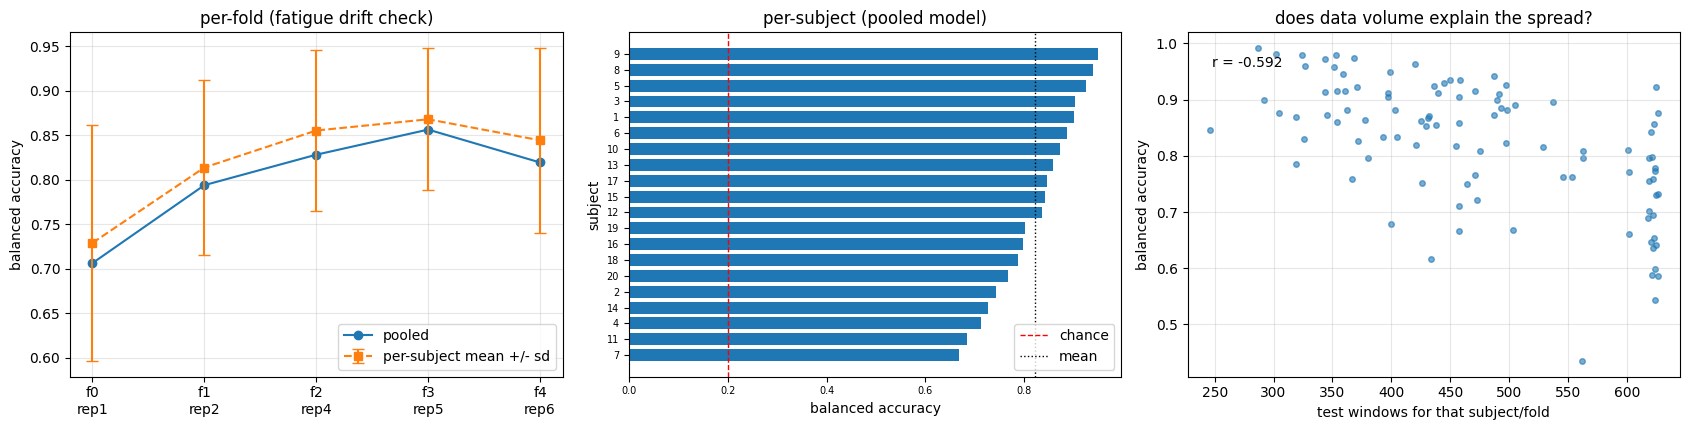

best  5 subjects: [9, 8, 5, 3, 1]  (bal_acc [0.9486, 0.9397, 0.9247, 0.9016, 0.9013])
worst 5 subjects: [7, 11, 4, 14, 2]  (bal_acc [0.6677, 0.6832, 0.713, 0.7258, 0.7418])
spread: 0.2808 <- large spread is normal for DB2; report it, do not hide it


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))

ax = axes[0]
ax.plot(df_pooled["fold"], df_pooled["bal_acc"], "o-", label="pooled")
_pf = df_sub.groupby("fold")["bal_acc"]
ax.errorbar(_pf.mean().index, _pf.mean().values, yerr=_pf.std().values,
            fmt="s--", capsize=4, label="per-subject mean +/- sd")
ax.set_xticks(range(CFG.n_folds))
ax.set_xticklabels([f"f{f}\nrep{CFG.test_reps[f]}" for f in range(CFG.n_folds)])
ax.set_ylabel("balanced accuracy"); ax.set_title("per-fold (fatigue drift check)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
_ps = per_subject.sort_values("bal_acc")
ax.barh([str(s) for s in _ps["subject"]], _ps["bal_acc"], height=0.75)
ax.axvline(1.0 / CFG.n_classes, color="r", ls="--", lw=1, label="chance")
ax.axvline(per_subject["bal_acc"].mean(), color="k", ls=":", lw=1, label="mean")
ax.set_xlabel("balanced accuracy"); ax.set_ylabel("subject")
ax.set_title("per-subject (pooled model)"); ax.legend(); ax.tick_params(labelsize=7)

ax = axes[2]
ax.scatter(df_sub["n_test"], df_sub["bal_acc"], s=16, alpha=0.6)
ax.set_xlabel("test windows for that subject/fold"); ax.set_ylabel("balanced accuracy")
ax.set_title("does data volume explain the spread?"); ax.grid(alpha=0.3)
_r = np.corrcoef(df_sub["n_test"], df_sub["bal_acc"])[0, 1]
ax.annotate(f"r = {_r:.3f}", xy=(0.05, 0.9), xycoords="axes fraction")
plt.tight_layout(); plt.show()

_k = max(1, min(5, len(_ps) // 3))          # keep best/worst disjoint for small n
print(f"best  {_k} subjects: {_ps['subject'].tail(_k).tolist()[::-1]}  "
      f"(bal_acc {_ps['bal_acc'].tail(_k).values[::-1].round(4).tolist()})")
print(f"worst {_k} subjects: {_ps['subject'].head(_k).tolist()}  "
      f"(bal_acc {_ps['bal_acc'].head(_k).values.round(4).tolist()})")
print(f"spread: {_ps['bal_acc'].max()-_ps['bal_acc'].min():.4f} "
      "<- large spread is normal for DB2; report it, do not hide it")

---
## Step 12 — Save for the significance notebook

Same schema as the per-subject notebook, so `03_significance.ipynb` reads either without change.

In [ ]:
STAMP = time.strftime("%Y%m%d_%H%M%S")
TAG = f"mvstgnn_pooled_{CFG.n_classes}cls_{CFG.win_ms}ms"


def _rel(p):
    try:
        return str(Path(p).relative_to(PROJECT))
    except ValueError:
        return str(p)


raw_p = RESULTS / f"{TAG}_per_fold_subject_{STAMP}.csv"
pol_p = RESULTS / f"{TAG}_pooled_per_fold_{STAMP}.csv"
sub_p = RESULTS / f"{TAG}_per_subject_{STAMP}.csv"
cfg_p = RESULTS / f"{TAG}_config_{STAMP}.json"

df_sub.to_csv(raw_p, index=False)
df_pooled.to_csv(pol_p, index=False)
out = per_subject.copy()
out.insert(0, "model", "MV-STGNN-pooled")
out["n_folds"] = CFG.n_folds
out["n_seeds"] = df_sub["seed"].nunique()
out["protocol"] = "pooled_subject_mixed_repetition_split"
out.to_csv(sub_p, index=False)
cfg_p.write_text(json.dumps(
    {k: (list(v) if isinstance(v, tuple) else v) for k, v in asdict(CFG).items()}, indent=2))

for p in (raw_p, pol_p, sub_p, cfg_p):
    print(f"  {_rel(p)}  ({p.stat().st_size/1024:.1f} KB)")
for s, d in ((raw_p, f"{TAG}_per_fold_subject_latest.csv"),
             (pol_p, f"{TAG}_pooled_per_fold_latest.csv"),
             (sub_p, f"{TAG}_per_subject_latest.csv")):
    (RESULTS / d).write_bytes(s.read_bytes())
    print(f"  {_rel(RESULTS / d)}")
display(out.round(4))

  results\tables\mvstgnn_pooled_5cls_200ms_per_fold_subject_20260806_233411.csv  (16.7 KB)
  results\tables\mvstgnn_pooled_5cls_200ms_pooled_per_fold_20260806_233411.csv  (0.9 KB)
  results\tables\mvstgnn_pooled_5cls_200ms_per_subject_20260806_233411.csv  (3.3 KB)
  results\tables\mvstgnn_pooled_5cls_200ms_config_20260806_233411.json  (1.9 KB)
  results\tables\mvstgnn_pooled_5cls_200ms_per_fold_subject_latest.csv
  results\tables\mvstgnn_pooled_5cls_200ms_pooled_per_fold_latest.csv
  results\tables\mvstgnn_pooled_5cls_200ms_per_subject_latest.csv


,model,subject,acc,bal_acc,macro_f1,weighted_f1,kappa,vote_acc,n_folds,n_seeds,protocol
0,MV-STGNN-pooled,1,0.8904,0.9013,0.8995,0.8901,0.8597,1.00,5,1,pooled_subject_mixed_repetition_split
1,MV-STGNN-pooled,2,0.7618,0.7418,0.7255,0.7461,0.6975,0.84,5,1,pooled_subject_mixed_repetition_split
2,MV-STGNN-pooled,3,0.9098,0.9016,0.8953,0.9092,0.8845,1.00,5,1,pooled_subject_mixed_repetition_split
3,MV-STGNN-pooled,4,0.7141,0.7130,0.7111,0.7120,0.6425,0.92,5,1,pooled_subject_mixed_repetition_split
4,MV-STGNN-pooled,5,0.9112,0.9247,0.9171,0.9087,0.8821,1.00,5,1,pooled_subject_mixed_repetition_split
5,MV-STGNN-pooled,6,0.8788,0.8861,0.8837,0.8760,0.8431,1.00,5,1,pooled_subject_mixed_repetition_split
6,MV-STGNN-pooled,7,0.6683,0.6677,0.6596,0.6598,0.5851,0.88,5,1,pooled_subject_mixed_repetition_split
7,MV-STGNN-pooled,8,0.9372,0.9397,0.9362,0.9359,0.9198,1.00,5,1,pooled_subject_mixed_repetition_split
8,MV-STGNN-pooled,9,0.9530,0.9486,0.9472,0.9528,0.9383,1.00,5,1,pooled_subject_mixed_repetition_split
9,MV-STGNN-pooled,10,0.8700,0.8714,0.8630,0.8652,0.8325,0.96,5,1,pooled_subject_mixed_repetition_split
